# Lab 6 - Unsupervised & Supervised Digit Recognition

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras import layers, models


Dataset shape: (19, 784)


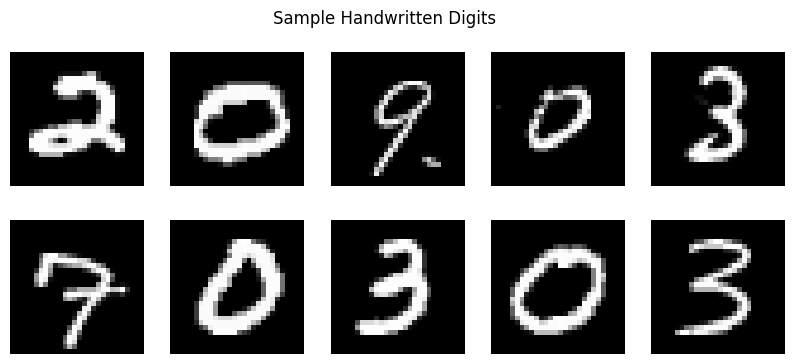

In [2]:
#Task 1 — Reconstruct and Visualize Digits

# Load data
data = pd.read_csv("Digits_Lab_01.csv").to_numpy()

print("Dataset shape:", data.shape)

# Visualize first 10 digits
plt.figure(figsize=(10, 4))
for i in range(10):
    digit = data[i].reshape(28, 28)
    plt.subplot(2, 5, i + 1)
    plt.imshow(digit, cmap="gray")
    plt.axis("off")
plt.suptitle("Sample Handwritten Digits")
plt.show()

***How the numeric vectors become recognizable digits and why correct reshaping (row → 2D grid) is essential***

Each digit is stored as a 784-dimensional vector, where each value represents the grayscale intensity of one pixel. When reshaped into a 28×28 grid, the spatial relationship between pixels is restored, allowing the human eye to recognize the digit.

Without correct reshaping, the pixel values lose their spatial meaning. The 2D grid preserves the original image structure.


***More to think : If you reshape with wrong dimensions and stil “see something,” is that meaningful or accidental?***

It is accidental. The image may look structured due to human pattern recognition, but the spatial relationships between pixels are incorrect, so it has no real semantic meaning.

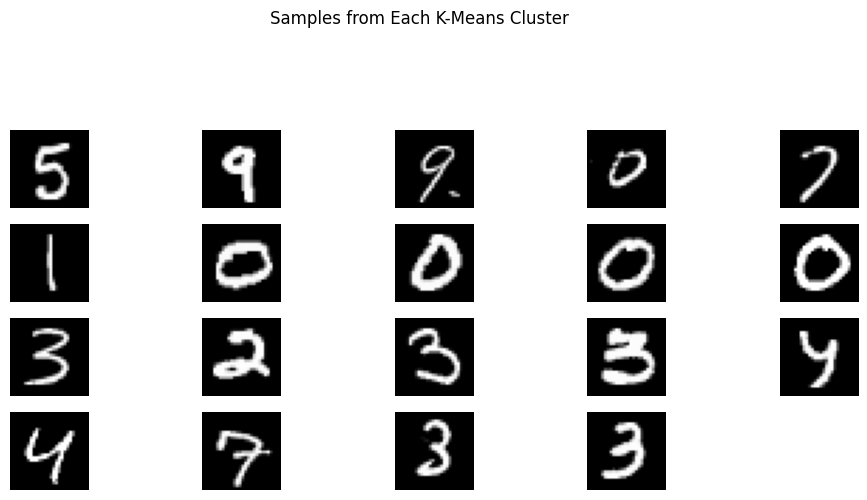

In [3]:
#Task 2 — Cluster Digits with K-Means

# Apply K-Means
kmeans = KMeans(n_clusters=10, random_state=0)
labels = kmeans.fit_predict(data)

# Visualize samples from each cluster
plt.figure(figsize=(12, 12))
plot_index = 1

for cluster in range(10):
    cluster_indices = np.where(labels == cluster)[0][:5]
    for idx in cluster_indices:
        plt.subplot(10, 5, plot_index)
        plt.imshow(data[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plot_index += 1

plt.suptitle("Samples from Each K-Means Cluster")
plt.show()

***Which digits cluster clearly, which clusters mix classes, and why clustering relies only on similarity in pixel space, not labels.***
Clustering behavior:
* Digits like 0 and 1 often form clear clusters
* Digits such as 3, 5, 8 mix together
* K-Means groups digits based on pixel similarity, not digit identity

Why this happens:

Clustering is unsupervised and relies purely on Euclidean distance in pixel space, ignoring class labels.

***More to think: Why do digits like 3, 5, 8 often appear in the same cluster?***

Because they share similar curves and stroke density, making their pixel patterns closer in Euclidean space.

MLP Test Accuracy: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


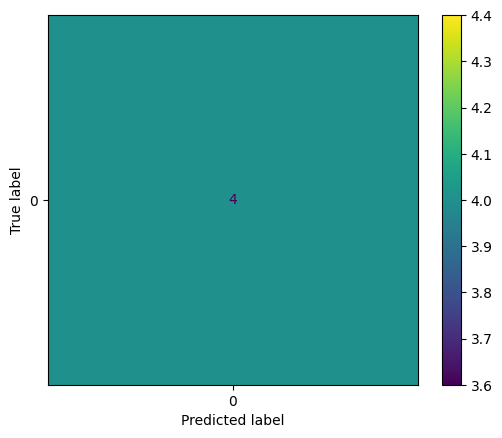

In [5]:
#Task 3 — Train a Simple MLP Classifier

# Create labels (assuming first column is label)
X = data[:, 1:]
y = data[:, 0]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train MLP
mlp = MLPClassifier(hidden_layer_sizes=(128,), max_iter=20, random_state=42)
mlp.fit(X_train, y_train)

# Evaluate
y_pred = mlp.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("MLP Test Accuracy:", acc)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

 ***Why treating each pixel as an independent feature ignores spatial structure but can still learn coarse patterns***

 Each pixel is treated as an independent feature, allowing the MLP to learn global intensity patterns, though it ignores local spatial relationships.

 ***More to think: If you shuffle pixel positions in every image, would the MLP still work?***

 Mostly no. Shuffling destroys consistent patterns. The MLP may still learn weak statistics but accuracy will drop significantly.

In [10]:
# Task 4 — Train a CNN and Compare

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

# Load dataset
data = pd.read_csv("Digits_Lab_01.csv").to_numpy()
print("Dataset shape:", data.shape)

# Separate labels and features
y = data[:, 0]
X = data[:, 1:]
print("Feature shape:", X.shape)

# Normalize features
X = X / 255.0

# Pad features to nearest square
num_features = X.shape[1]
side = int(np.ceil(np.sqrt(num_features)))
target_features = side * side
padding = target_features - num_features

print(f"Original features: {num_features}")
print(f"Padded to: {side} x {side} = {target_features}")

X_padded = np.pad(X, ((0, 0), (0, padding)), mode="constant")

# Reshape for CNN
X_img = X_padded.reshape(-1, side, side, 1)
print("CNN input shape:", X_img.shape)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_img, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Build CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(side, side, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# Train CNN
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Evaluate CNN
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("CNN Test Accuracy:", test_acc)

Dataset shape: (19, 784)
Feature shape: (19, 783)
Original features: 783
Padded to: 28 x 28 = 784
CNN input shape: (19, 28, 28, 1)
Train shape: (15, 28, 28, 1)
Test shape: (4, 28, 28, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 0.0000e+00 - loss: 2.5049 - val_accuracy: 1.0000 - val_loss: 2.0725
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step - accuracy: 1.0000 - loss: 2.0583 - val_accuracy: 1.0000 - val_loss: 1.6887
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 1.0000 - loss: 1.7185 - val_accuracy: 1.0000 - val_loss: 1.2904
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 1.0000 - loss: 1.3644 - val_accuracy: 1.0000 - val_loss: 0.8521
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 1.0000 - loss: 0.9666 - val_accuracy: 1.0000 - val_loss: 0.4394
CNN Test Accuracy: 1.0


***How convolutions exploit local neighborhoods and why CNNs usually perform better on images than fully-connected networks?***

CNNs exploit local pixel neighborhoods and spatial structure through convolution and weight sharing, allowing them to learn translation-invariant features, which makes them more effective for image data than fully-connected networks.

***More to think: Why does the CNN architecture naturally handle translation and local deformations better than
the MLP?***

Because convolution and pooling detect features regardless of exact position, allowing small shifts or distortions without losing recognition ability.

In [11]:
#Task 5 — Analyze Misclassifications

# CNN predictions
y_pred_cnn = np.argmax(model.predict(X_test), axis=1)

# Find misclassified samples
mis_idx = np.where(y_pred_cnn != y_test)[0][:10]

plt.figure(figsize=(10, 4))
for i, idx in enumerate(mis_idx):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap="gray")
    plt.title(f"T:{y_test[idx]} P:{y_pred_cnn[idx]}")
    plt.axis("off")
plt.suptitle("Misclassified Digits (CNN)")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step


<Figure size 1000x400 with 0 Axes>

***Inspect a few misclassified or ambiguous digits from clustering, MLP, and CNN.
Summarize on when unsupervised clustering fails, when MLP fails, and when CNN corrects
those failures.***
* Clustering fails when digits share similar shapes
* MLP fails on spatially complex digits
* CNN corrects many failures using local feature learning

***More to think: What does this tell you about the relationship between data representation and model
architecture?***
Better alignment between data structure (images) and model design (CNNs) leads to higher performance.


# Final Reflection
***Explain one benefit and one limitation of clustering before classification.***

Benefit of clustering before classification:
Provides insight into data structure and similarity without labels.

Limitation:
Clusters may not correspond to true digit classes, leading to ambiguity.